In [4]:
import numpy as np
import joblib
import torch

# Load saved ESM embeddings
X_embeddings = np.load("../models/X_embeddings.npy")

# Load encoded labels
y_labels = np.load("../models/y_labels.npy")

print("ESM Embeddings Shape:", X_embeddings.shape)
print("Labels Shape:", y_labels.shape)
print("Number of Classes:", len(np.unique(y_labels)))

ESM Embeddings Shape: (15000, 320)
Labels Shape: (15000,)
Number of Classes: 3


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import joblib

# Encode string labels to integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)

# Save label encoder for future use
joblib.dump(label_encoder, "../models/attention_label_encoder.pkl")

print("Classes:", label_encoder.classes_)
print("Encoded labels:", np.unique(y_encoded))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_embeddings,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Data loaders
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Data loaders created successfully.")

Classes: ['binding' 'enzyme' 'transport']
Encoded labels: [0 1 2]
Training Set: (12000, 320)
Testing Set: (3000, 320)
Data loaders created successfully.


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class ESMAttentionModel(nn.Module):
    def __init__(self, input_dim=320, hidden_dim=128, num_classes=3):
        super(ESMAttentionModel, self).__init__()

        # Attention layer
        self.attention = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.Tanh(),
            nn.Linear(input_dim, input_dim),
            nn.Softmax(dim=1)
        )

        # Classification layers
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, return_attention=False):
        # Compute attention weights
        attention_weights = self.attention(x)

        # Apply attention element-wise
        weighted_x = x * attention_weights

        # Classification head
        x = F.relu(self.fc1(weighted_x))
        x = self.dropout(x)
        logits = self.fc2(x)

        if return_attention:
            return logits, attention_weights

        return logits


# Automatically detect input dimension from embeddings
INPUT_DIM = X_embeddings.shape[1]   # 320 in your case
NUM_CLASSES = len(np.unique(y_encoded))

# Create model
model = ESMAttentionModel(
    input_dim=INPUT_DIM,
    hidden_dim=128,
    num_classes=NUM_CLASSES
)

print(model)
print("Model created successfully.")

ESMAttentionModel(
  (attention): Sequential(
    (0): Linear(in_features=320, out_features=320, bias=True)
    (1): Tanh()
    (2): Linear(in_features=320, out_features=320, bias=True)
    (3): Softmax(dim=1)
  )
  (fc1): Linear(in_features=320, out_features=128, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
)
Model created successfully.


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Move model to device
model = model.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Number of epochs
EPOCHS = 20

# Training loop
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    for batch_X, batch_y in train_loader:
        # Move data to device
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(batch_X)

        # Compute loss
        loss = criterion(outputs, batch_y)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Accumulate loss
        total_loss += loss.item()

    # Average loss for this epoch
    avg_loss = total_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{EPOCHS}] - Loss: {avg_loss:.4f}")

Using device: cpu
Epoch [1/20] - Loss: 0.8333
Epoch [2/20] - Loss: 0.6322
Epoch [3/20] - Loss: 0.3541
Epoch [4/20] - Loss: 0.2603
Epoch [5/20] - Loss: 0.2236
Epoch [6/20] - Loss: 0.2054
Epoch [7/20] - Loss: 0.1935
Epoch [8/20] - Loss: 0.1862
Epoch [9/20] - Loss: 0.1742
Epoch [10/20] - Loss: 0.1646
Epoch [11/20] - Loss: 0.1617
Epoch [12/20] - Loss: 0.1508
Epoch [13/20] - Loss: 0.1415
Epoch [14/20] - Loss: 0.1397
Epoch [15/20] - Loss: 0.1316
Epoch [16/20] - Loss: 0.1290
Epoch [17/20] - Loss: 0.1250
Epoch [18/20] - Loss: 0.1192
Epoch [19/20] - Loss: 0.1164
Epoch [20/20] - Loss: 0.1092


In [9]:
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Evaluation mode
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)

        # Forward pass
        outputs = model(batch_X)

        # Predicted class
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        # Store predictions and true labels
        all_preds.extend(preds)
        all_labels.extend(batch_y.numpy())

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Accuracy
accuracy = accuracy_score(all_labels, all_preds)

print("ESM + Attention Accuracy:", accuracy)

# Classification report
print("\nClassification Report:\n")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=label_encoder.classes_
    )
)

ESM + Attention Accuracy: 0.9396666666666667

Classification Report:

              precision    recall  f1-score   support

     binding       0.92      0.94      0.93      1000
      enzyme       0.97      0.92      0.94      1000
   transport       0.93      0.95      0.94      1000

    accuracy                           0.94      3000
   macro avg       0.94      0.94      0.94      3000
weighted avg       0.94      0.94      0.94      3000



In [12]:
import torch

# Save the trained attention model
torch.save(
    model.state_dict(),
    "../models/esm_attention_model.pth"
)

print("ESM + Self-Attention model saved successfully!")

ESM + Self-Attention model saved successfully!


In [13]:
import torch

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "input_dim": X_embeddings.shape[1],
        "hidden_dim": 128,
        "num_classes": len(label_encoder.classes_),
        "class_names": label_encoder.classes_
    },
    "../models/esm_attention_checkpoint.pth"
)

print("Complete attention checkpoint saved successfully!")

Complete attention checkpoint saved successfully!


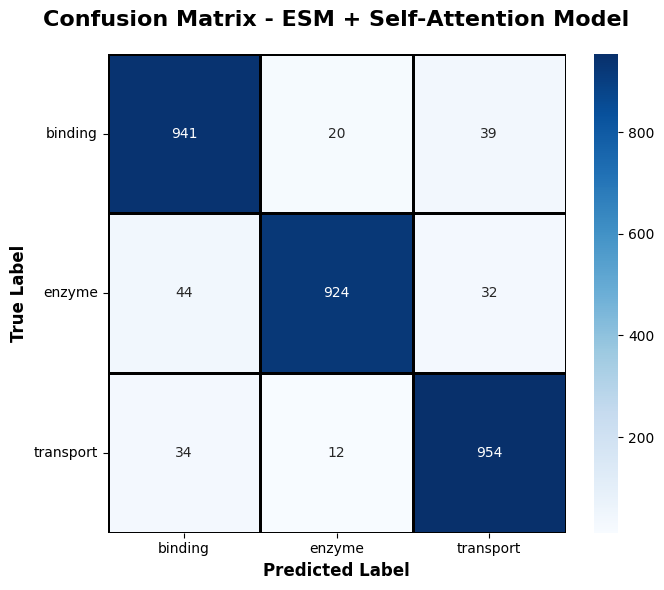

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    linewidths=1,
    linecolor="black"
)

plt.title(
    "Confusion Matrix - ESM + Self-Attention Model",
    fontsize=16,
    fontweight="bold",
    pad=20
)
plt.xlabel("Predicted Label", fontsize=12, fontweight="bold")
plt.ylabel("True Label", fontsize=12, fontweight="bold")
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# 5-fold cross-validation on ESM + self-Attention Model

In [11]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Cross-validation settings
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_embeddings, y_encoded), 1):
    print(f"\n===== Fold {fold}/5 =====")

    # Split data
    X_train_fold = X_embeddings[train_idx]
    X_val_fold = X_embeddings[val_idx]
    y_train_fold = y_encoded[train_idx]
    y_val_fold = y_encoded[val_idx]

    # Convert to tensors
    X_train_tensor = torch.tensor(X_train_fold, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_fold, dtype=torch.long)
    X_val_tensor = torch.tensor(X_val_fold, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val_fold, dtype=torch.long)

    # DataLoader
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

    # New model for each fold
    model_cv = ESMAttentionModel(
        input_dim=X_embeddings.shape[1],
        hidden_dim=128,
        num_classes=len(np.unique(y_encoded))
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model_cv.parameters(), lr=0.001)

    # Train for 10 epochs (enough for CV)
    EPOCHS = 10

    for epoch in range(EPOCHS):
        model_cv.train()

        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()
            outputs = model_cv(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

    # Validation
    model_cv.eval()

    with torch.no_grad():
        outputs = model_cv(X_val_tensor.to(device))
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

    acc = accuracy_score(y_val_fold, preds)
    cv_scores.append(acc)

    print(f"Fold {fold} Accuracy: {acc:.4f}")

# Final results
cv_scores = np.array(cv_scores)

print("\nCross-Validation Scores:", cv_scores)
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")
print(f"Final Result: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


===== Fold 1/5 =====
Fold 1 Accuracy: 0.9450

===== Fold 2/5 =====
Fold 2 Accuracy: 0.9230

===== Fold 3/5 =====
Fold 3 Accuracy: 0.9357

===== Fold 4/5 =====
Fold 4 Accuracy: 0.9413

===== Fold 5/5 =====
Fold 5 Accuracy: 0.9347

Cross-Validation Scores: [0.945      0.923      0.93566667 0.94133333 0.93466667]
Mean Accuracy: 0.9359
Standard Deviation: 0.0075
Final Result: 0.9359 ± 0.0075


# Weighted Soft Voting Ensemble of ESM + SVC and ESM + Self-Attention

In [15]:
# Load ESM + SVC model
svc_model = joblib.load("../models/final_esm_model.pkl")

# Load saved weights
state_dict = torch.load(
    "../models/esm_attention_model.pth",
    map_location=torch.device("cpu")
)

# Create model instance
attention_model = ESMAttentionModel(
    input_dim=320,
    hidden_dim=128,
    num_classes=3
)

# Load weights
attention_model.load_state_dict(state_dict)

# Evaluation mode
attention_model.eval()

print("Models loaded successfully!")

Models loaded successfully!


In [17]:
# Load saved ESM embeddings
X_embeddings = np.load("../models/X_embeddings.npy")

# Load labels
y_labels = np.load("../models/y_labels.npy", allow_pickle=True)

# Encode labels
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)

print("Embeddings shape:", X_embeddings.shape)
print("Classes:", label_encoder.classes_)

Embeddings shape: (15000, 320)
Classes: ['binding' 'enzyme' 'transport']


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_embeddings,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Test set shape:", X_test.shape)

Test set shape: (3000, 320)


In [19]:
# Probability predictions from SVC
svc_probs = svc_model.predict_proba(X_test)

print("SVC probabilities shape:", svc_probs.shape)

SVC probabilities shape: (3000, 3)


In [20]:
# Convert test data to tensor
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

with torch.no_grad():
    outputs = attention_model(X_test_tensor)
    attention_probs = F.softmax(outputs, dim=1).numpy()

print("Attention probabilities shape:", attention_probs.shape)

Attention probabilities shape: (3000, 3)


In [21]:
# Weights
w_svc = 0.6
w_attention = 0.4

# Combine probabilities
ensemble_probs = (w_svc * svc_probs) + (w_attention * attention_probs)

# Final predictions
y_pred_ensemble = np.argmax(ensemble_probs, axis=1)

print("Ensemble predictions generated.")

Ensemble predictions generated.


In [22]:
accuracy = accuracy_score(y_test, y_pred_ensemble)

print("Ensemble Accuracy:", accuracy)
print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        y_pred_ensemble,
        target_names=label_encoder.classes_
    )
)

Ensemble Accuracy: 0.9456666666666667

Classification Report:

              precision    recall  f1-score   support

     binding       0.93      0.95      0.94      1000
      enzyme       0.96      0.93      0.95      1000
   transport       0.94      0.96      0.95      1000

    accuracy                           0.95      3000
   macro avg       0.95      0.95      0.95      3000
weighted avg       0.95      0.95      0.95      3000



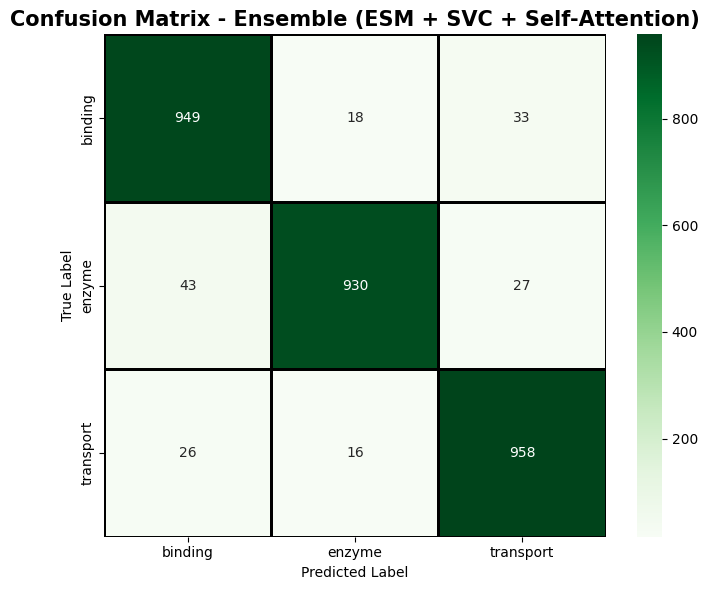

In [23]:
cm = confusion_matrix(y_test, y_pred_ensemble)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    linewidths=1,
    linecolor="black"
)

plt.title(
    "Confusion Matrix - Ensemble (ESM + SVC + Self-Attention)",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [24]:
np.save("../models/ensemble_predictions.npy", y_pred_ensemble)

print("Ensemble predictions saved successfully.")

Ensemble predictions saved successfully.


In [25]:
import joblib

ensemble_artifacts = {
    "svc_model": svc_model,
    "label_encoder": label_encoder
}

joblib.dump(
    ensemble_artifacts,
    "../models/final_ensemble_model.pkl"
)

print("Ensemble model artifacts saved successfully!")

Ensemble model artifacts saved successfully!


In [26]:
np.save("../models/ensemble_probs.npy", ensemble_probs)
print("Ensemble probabilities saved.")

Ensemble probabilities saved.


In [27]:
np.save("../models/X_test_embeddings.npy", X_test)
np.save("../models/y_test_encoded.npy", y_test)
print("Test data saved.")

Test data saved.
